In [1]:
import pandas as pd
import json
from geopy.distance import geodesic
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


train_values = pd.read_csv("train_values.csv")
train_labels = pd.read_csv("train_labels.csv")


df_raw = pd.merge(train_values, train_labels, on="building_id")


non_structural_cols = [
    'building_id', 
    'geo_level_1_id',  
    'geo_level_3_id', 
    'legal_ownership_status',
    'position',
    'count_families'
    ]

secondary_use_cols = [col for col in df_raw.columns if col.startswith('has_secondary_use')]
cols_to_drop = non_structural_cols + secondary_use_cols
df_final = df_raw.drop(columns= cols_to_drop)


print(f"Shape after filtering: {df_final.shape}")

Shape after filtering: (260601, 23)


In [2]:
df_final

,geo_level_2_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,damage_grade
0,487,2,30,6,5,t,r,n,f,q,...,0,0,0,0,0,0,0,0,0,3
1,900,2,10,8,7,o,r,n,x,q,...,0,0,0,0,0,0,0,0,0,2
2,363,2,10,5,5,t,r,n,f,x,...,0,0,0,0,0,0,0,0,0,3
3,418,2,10,6,5,t,r,n,f,x,...,0,0,0,0,1,1,0,0,0,2
4,131,3,30,8,9,t,r,n,f,x,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,1335,1,55,6,3,n,r,n,f,j,...,0,0,0,0,0,0,0,0,0,2
260597,715,2,0,6,5,t,r,n,f,q,...,0,0,0,0,0,0,0,0,0,3
260598,51,3,55,6,7,t,r,q,f,q,...,0,0,0,0,0,0,0,0,0,3
260599,39,2,10,14,6,t,r,x,v,s,...,0,0,0,1,0,0,0,0,0,2


In [3]:
EPICENTER = (28.231, 84.731)


with open("GEO_LEVEL_2_MAP.json", 'r') as f:
    geo_dict = json.load(f)


distance_map = {}
for k, v in geo_dict.items():
    if isinstance(v, dict) and 'lat' in v and 'lon' in v:
        point = (v['lat'], v['lon'])
        # Calculate distance and store it with an integer key
        distance_map[int(k)] = np.round(geodesic(point, EPICENTER).kilometers, 2)
    else:
        distance_map[int(k)] = None


df_final["epicenter_distance"] = df_final["geo_level_2_id"].map(distance_map)
df_final = df_final.drop(columns=['geo_level_2_id'])



# 1. Model how shaking force decays over distance
df_final['hazard_force'] = 1.0 - (np.log1p(df_final['epicenter_distance']) / 5.0)
df_final['hazard_force'] = np.clip(df_final['hazard_force'], 0.05, 1.0)

# 2. Normalize the categorical damage grade (1, 2, 3) to a 0.0 - 1.0 range
df_final['damage_norm'] = (df_final['damage_grade'] - 1) / 2.0

# 3. Calculate vulnerability (Damage sustained relative to the force felt)
df_final['vulnerability'] = df_final['damage_norm'] / (df_final['hazard_force'] + 0.1)

# 4. Invert vulnerability to get Resilience, and scale from 0 to 100
raw_resilience = 1.0 / (df_final['vulnerability'] + 0.2)

min_r = raw_resilience.min()
max_r = raw_resilience.max()

df_final['resilience_score'] = ((raw_resilience - min_r) / (max_r - min_r)) * 100.0

epicenter_series = df_final['epicenter_distance']

df_final = df_final.drop(columns=["damage_grade", 'hazard_force', 'damage_norm', 'vulnerability', 'epicenter_distance'])
df_final.to_csv('resilence_dataset_0.csv')
df_final

,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,plan_configuration,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,resilience_score
0,2,30,6,5,t,r,n,f,q,d,...,0,0,0,0,0,0,0,0,0,0.000000
1,2,10,8,7,o,r,n,x,q,d,...,0,0,0,0,0,0,0,0,0,3.032680
2,2,10,5,5,t,r,n,f,x,d,...,0,0,0,0,0,0,0,0,0,0.000000
3,2,10,6,5,t,r,n,f,x,d,...,0,0,0,0,1,1,0,0,0,13.079632
4,3,30,8,9,t,r,n,f,x,d,...,0,0,0,0,0,0,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,1,55,6,3,n,r,n,f,j,q,...,0,0,0,0,0,0,0,0,0,10.094963
260597,2,0,6,5,t,r,n,f,q,d,...,0,0,0,0,0,0,0,0,0,1.272464
260598,3,55,6,7,t,r,q,f,q,d,...,0,0,0,0,0,0,0,0,0,0.537086
260599,2,10,14,6,t,r,x,v,s,d,...,0,0,0,1,0,0,0,0,0,4.688472


In [4]:
for i in range(0,100,5):
    print(
        f"{i}% to {i+5}%: {df_final['resilience_score'][(df_final['resilience_score']>i)\
                                         & (df_final['resilience_score']<=i+5)].count()} rows"
        )

0% to 5%: 136598 rows
5% to 10%: 45428 rows
10% to 15%: 11476 rows
15% to 20%: 1712 rows
20% to 25%: 450 rows
25% to 30%: 0 rows
30% to 35%: 0 rows
35% to 40%: 0 rows
40% to 45%: 0 rows
45% to 50%: 0 rows
50% to 55%: 0 rows
55% to 60%: 0 rows
60% to 65%: 0 rows
65% to 70%: 0 rows
70% to 75%: 0 rows
75% to 80%: 0 rows
80% to 85%: 0 rows
85% to 90%: 0 rows
90% to 95%: 0 rows
95% to 100%: 25124 rows


In [5]:
epicenter_series.corr(df_final['resilience_score'], method= 'spearman')

np.float64(-0.5647451452182911)

TRAINING

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split


df = pd.read_csv('resilence_dataset_0.csv', index_col=['Unnamed: 0'])

categorical_cols = ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'plan_configuration']

df[categorical_cols] = df[categorical_cols].astype('category')

X = df.drop(columns= ['resilience_score'])
y = df['resilience_score']
print("Features the model will train on:", list(X.columns))
df

Features the model will train on: ['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other']


,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,plan_configuration,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,resilience_score
0,2,30,6,5,t,r,n,f,q,d,...,0,0,0,0,0,0,0,0,0,0.000000
1,2,10,8,7,o,r,n,x,q,d,...,0,0,0,0,0,0,0,0,0,3.032680
2,2,10,5,5,t,r,n,f,x,d,...,0,0,0,0,0,0,0,0,0,0.000000
3,2,10,6,5,t,r,n,f,x,d,...,0,0,0,0,1,1,0,0,0,13.079632
4,3,30,8,9,t,r,n,f,x,d,...,0,0,0,0,0,0,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,1,55,6,3,n,r,n,f,j,q,...,0,0,0,0,0,0,0,0,0,10.094963
260597,2,0,6,5,t,r,n,f,q,d,...,0,0,0,0,0,0,0,0,0,1.272464
260598,3,55,6,7,t,r,q,f,q,d,...,0,0,0,0,0,0,0,0,0,0.537086
260599,2,10,14,6,t,r,x,v,s,d,...,0,0,0,1,0,0,0,0,0,4.688472


In [8]:
# Split into train and evaluation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# 1. Scale target vector to 0-1 range for the logistic function
y_train_scaled = y_train / 100.0
y_test_scaled = y_test / 100.0

# 2. Re-initialize model with logistic regression objective
regressor = xgb.XGBRegressor(
    objective="reg:logistic",  # Out-of-the-box probability constraint (0 to 1)
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    enable_categorical=True,
    random_state=42
)

regressor.fit(X_train, y_train_scaled)

# 3. Predict and scale back to 0-100 range
preds_scaled = regressor.predict(X_test)
y_pred_logistic = preds_scaled * 100.0

regressor.fit(X_train, y_train_scaled)
print("Model training complete. Your resilience engine is ready for global deployment!")

Model training complete. Your resilience engine is ready for global deployment!


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = regressor.predict(X_test)
y_pred *= 100

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MODEL TEST RESULTS ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

=== MODEL TEST RESULTS ===
Mean Absolute Error (MAE): 12.85
Root Mean Squared Error (RMSE): 24.30
R-squared Score (R2): 0.2958


--- TOP 10 WORST PREDICTIONS ---
        Actual_Resilience  Predicted_Resilience  Absolute_Error
222471              100.0              1.491859       98.508141
137317              100.0              2.236007       97.763993
239480              100.0              2.246479       97.753521
209979              100.0              2.390848       97.609152
218690              100.0              2.883543       97.116457
41123               100.0              3.133724       96.866276
190917              100.0              3.145875       96.854125
118757              100.0              3.192038       96.807962
219502              100.0              3.345932       96.654068
254554              100.0              3.388760       96.611240


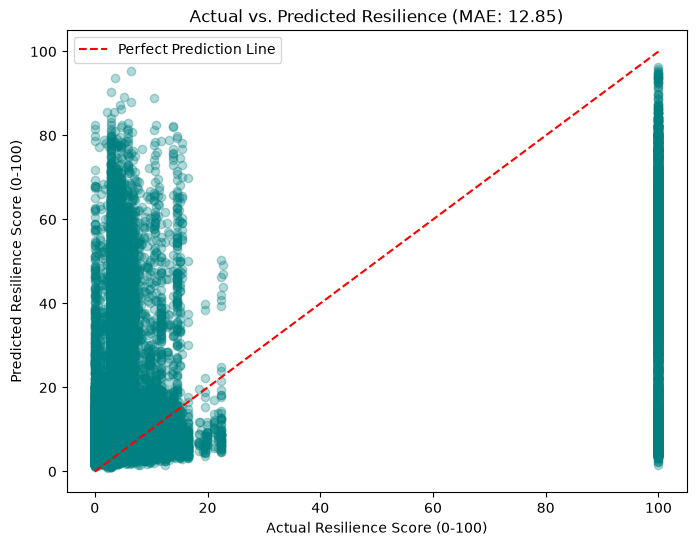

In [10]:
# Create an inspection DataFrame
df_inspect = pd.DataFrame({
    'Actual_Resilience': y_test,
    'Predicted_Resilience': y_pred,
    'Absolute_Error': np.abs(y_test - y_pred)
})

# Look at your 10 worst predictions to identify edge cases
print("--- TOP 10 WORST PREDICTIONS ---")
print(df_inspect.sort_values(by='Absolute_Error', ascending=False).head(10))

plt.figure(figsize=(8, 6))
plt.scatter(df_inspect['Actual_Resilience'], df_inspect['Predicted_Resilience'], alpha=0.3, color='teal')
plt.plot([0, 100], [0, 100], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel('Actual Resilience Score (0-100)')
plt.ylabel('Predicted Resilience Score (0-100)')
plt.title(f'Actual vs. Predicted Resilience (MAE: {mae:.2f})')
plt.legend()
plt.show()

In [11]:
# Square the residuals to see what RMSE is seeing
df_inspect['Squared_Error'] = (df_inspect['Actual_Resilience'] - df_inspect['Predicted_Resilience']) ** 2

# Isolate the worst 1% of errors skewing your metric
outlier_threshold = df_inspect['Squared_Error'].quantile(0.99)
rmse_outliers = df_inspect[df_inspect['Squared_Error'] >= outlier_threshold]

print(f"The top 1% worst predictions are contributing significantly to your RMSE score.")
# Pull original data features for these indexes to check if they share a specific property (e.g., specific foundation type)
df.loc[rmse_outliers.index].head()

The top 1% worst predictions are contributing significantly to your RMSE score.


,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,plan_configuration,...,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,resilience_score
29047,2,100,13,6,t,r,n,f,q,d,...,0,0,0,0,0,0,0,0,0,100.0
230385,2,30,7,6,n,r,n,x,q,d,...,0,0,0,0,0,0,0,0,0,100.0
183516,2,10,8,5,t,r,q,f,q,d,...,0,0,0,0,0,0,0,0,0,100.0
87452,3,20,11,7,n,w,n,x,x,d,...,0,0,0,0,0,0,0,0,0,100.0
2712,3,25,6,8,t,r,n,f,q,d,...,0,0,0,0,0,0,0,0,0,100.0
